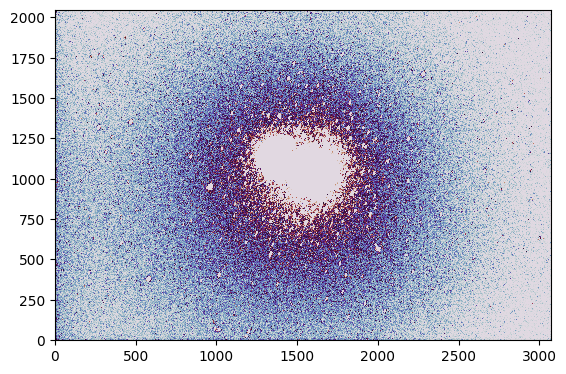

Aligning: /net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/20210418_Li_.00000052.FIT
Failed
Aligning: /net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/20210418_Li_.00000055.FIT
Failed
Aligning: /net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/20210418_Li_.00000060.FIT
Failed
Aligning: /net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/20210418_Li_.00000036.FIT
Aligning: /net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/20210418_Li_.00000044.FIT
Aligning: /net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/20210418_Li_.00000038.FIT
Aligning: /net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/20210418_Li_.00000043.FIT
Aligning: /net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/20210418_Li_.00000061.FIT
Failed
Aligning: /net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/20210418_Li_.00000054.FIT
Failed
Aligning: /net/dataserver3/data/users/

In [ ]:
from pathlib import Path
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval
import numpy as np
from matplotlib.pyplot import subplots, show
import astroalign as aa
from astropy.io import fits
#obtain the data
datadir = "/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/"
excludes = ['BIAS', 'FLAT', 'DARK']
path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)

#function imdisplay
def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

#read images and store them
images = []
for filepath in filepaths:
    hdulist = fits.open(filepath)
    images.append(hdulist[0].data.astype('float'))
    hdulist.close()

#stacking of raw images
datacube = np.stack(images)
stacked_images = np.median(datacube, axis=0)

#show raw stacked images
fig, ax = subplots()
imdisplay(stacked_images, ax, percentlow=5, percenthigh=95, scale='squared', cmap='twilight')
show()

#selecting a target image for astroalign
target = filepaths[len(filepaths)//2]  # pick middle file as target since middle file is usually most representative
hdulist = fits.open(target)
target_im = hdulist[0].data.astype('float')

aligned_images = []
for filepath in filepaths:
    if not filepath.name in excludes:
        print(f"Aligning: {filepath}")
        hdulist = fits.open(filepath)
        tobealigned_im = hdulist[0].data.astype('float')
        try:
            aligned_im, footprint = aa.register(tobealigned_im,
                                                target_im,
                                                detection_sigma=5.0,
                                                max_control_points=100,
                                                min_area=5)
            aligned_images.append(aligned_im)
        except:
            print("Failed")
        hdulist.close()

#stack the aligned images
datacube_aligned = np.stack(aligned_images)
stacked_aligned_images = np.median(datacube_aligned, axis = 0)

#show aligned and stacked images
fig, ax = plt.subplots()
imdisplay(np.flipud(stacked_reg_images), ax, percentlow=5, percenthigh=95,
          scale='squared', cmap='twilight')
show()
